# 01 Region Setup

SFINCS owns the hydraulic coverage around the selected SMART-DS subregion. Wflow owns the larger HUC watershed that drains into that selected coverage. The only notebook-facing domain choice is the Location override entry in `locations/<name>/domain.yaml`.

**Methodological Stages:**

Workflow sections:

### 1. Parameters and Configuration

Load the Location config and show the path syntax used for local records.

### 2. Footprint and Watershed

Build/read the SMART-DS evaluation footprint, write the selected SFINCS coverage box, fetch/select the enclosing WBD HUC watershed, and plot the relationship.

### 3. Required Static Data

Collect Wflow static inputs first over the larger HUC-derived boundary, then collect SFINCS static inputs over the selected hydraulic coverage.

### 4. Collected Input Plot

Plot the DEM, landcover, hydrologic soil group, and saturated-conductivity rasters for both model domains.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

notebook_root = Path.cwd().resolve()
location_root = notebook_root.parent
repo_root = location_root.parents[1]
src_root = repo_root / "src"
src_path = str(src_root)
if src_path in sys.path:
    sys.path.remove(src_path)
sys.path.insert(0, src_path)
importlib.invalidate_caches()
for module_name in [name for name in sys.modules if name == "sfincs_runs" or name.startswith("sfincs_runs.")]:
    del sys.modules[module_name]

import sfincs_runs.build_base.region_notebook as region

pd.set_option("display.max_colwidth", 140)


## Imports and Runtime


In [2]:
runtime = region.load_region_setup_notebook_runtime(location_root)

pd.Series(
    {
        "location": runtime.config["project"]["place_name"],
        "selected_sfincs_domain_ids": runtime.sfincs_config["sfincs_domain_set"]["include_domain_ids"],
        "source_record_syntax": 'location_root / "data" / "sources" / "..."',
        "static_record_syntax": 'location_root / "data" / "static" / "..."',
    },
    name="region_setup_parameters",
)


location                                                 Austin, TX, USA
selected_sfincs_domain_ids                                  [austin_p4u]
source_record_syntax          location_root / "data" / "sources" / "..."
static_record_syntax           location_root / "data" / "static" / "..."
Name: region_setup_parameters, dtype: object

## SMART-DS AOI and Evaluation Footprint

study_area                          locations/austin/data/static/aoi/study_area.geojson
evaluation_footprint      locations/austin/data/static/aoi/evaluation_footprint.geojson
source_format                                                        smart_ds_buscoords
subregion_count                                                                       6
bounds                                   (-98.182095, 30.025467, -97.375456, 30.637603)
minimum_flood_coverage                                                             True
Name: smart_ds_aoi, dtype: object

selected_sfincs_domain_ids                                                           austin_p4u
sfincs_coverage                                   locations/austin/data/static/aoi/bbox.geojson
wflow_huc_watersheds          locations/austin/data/static/aoi/wflow_nhdplus_watersheds.geojson
wflow_collection_boundary      locations/austin/data/static/aoi/wflow_collection_region.geojson
wbd_service                    https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer
huc_level                                                                                     8
huc_kind                                                                                  union
Name: selected_inland_region_domains, dtype: str

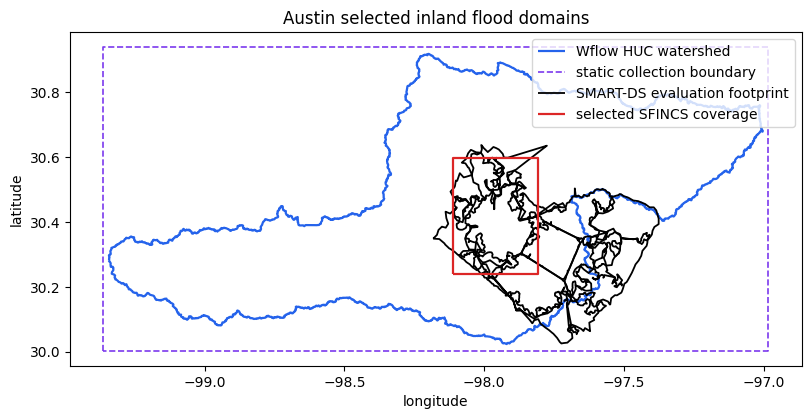

In [3]:
domains = region.build_selected_inland_region_domains(runtime)

display(domains.footprint.summary)
display(domains.summary)
region.plot_selected_inland_region(runtime, domains)
plt.show()


## SFINCS and Wflow Terrain/Landcover Inputs

In [4]:
static_data = region.collect_required_inland_static_data(runtime)

display(static_data.wflow_summary)
static_data.sfincs_summary


dem                            /home/grahamhults/projects/Flood-RM/locations/austin/data/wflow/static/processed/dem_wflow_coarse.tif
landcover                /home/grahamhults/projects/Flood-RM/locations/austin/data/wflow/static/processed/landcover_wflow_coarse.tif
dem_pixels                                                                                                                   2750800
landcover_pixels                                                                                                             2750800
ssurgo_polygons                                                                                                                62427
ssurgo_attribute_rows                                                                                                           3549
soil_mukeys                                                                                                                      880
hsg                                       /home/grahamhults/projects/

dem                            /home/grahamhults/projects/Flood-RM/locations/austin/data/static/processed/dem_region_setup.tif
landcover                /home/grahamhults/projects/Flood-RM/locations/austin/data/static/processed/landcover_region_setup.tif
dem_pixels                                                                                                            12713534
landcover_pixels                                                                                                      12713534
ssurgo_polygons                                                                                                          17422
ssurgo_attribute_rows                                                                                                     1281
soil_mukeys                                                                                                                342
hsg                                      /home/grahamhults/projects/Flood-RM/locations/austin/data/static/soils

## Region Setup QA


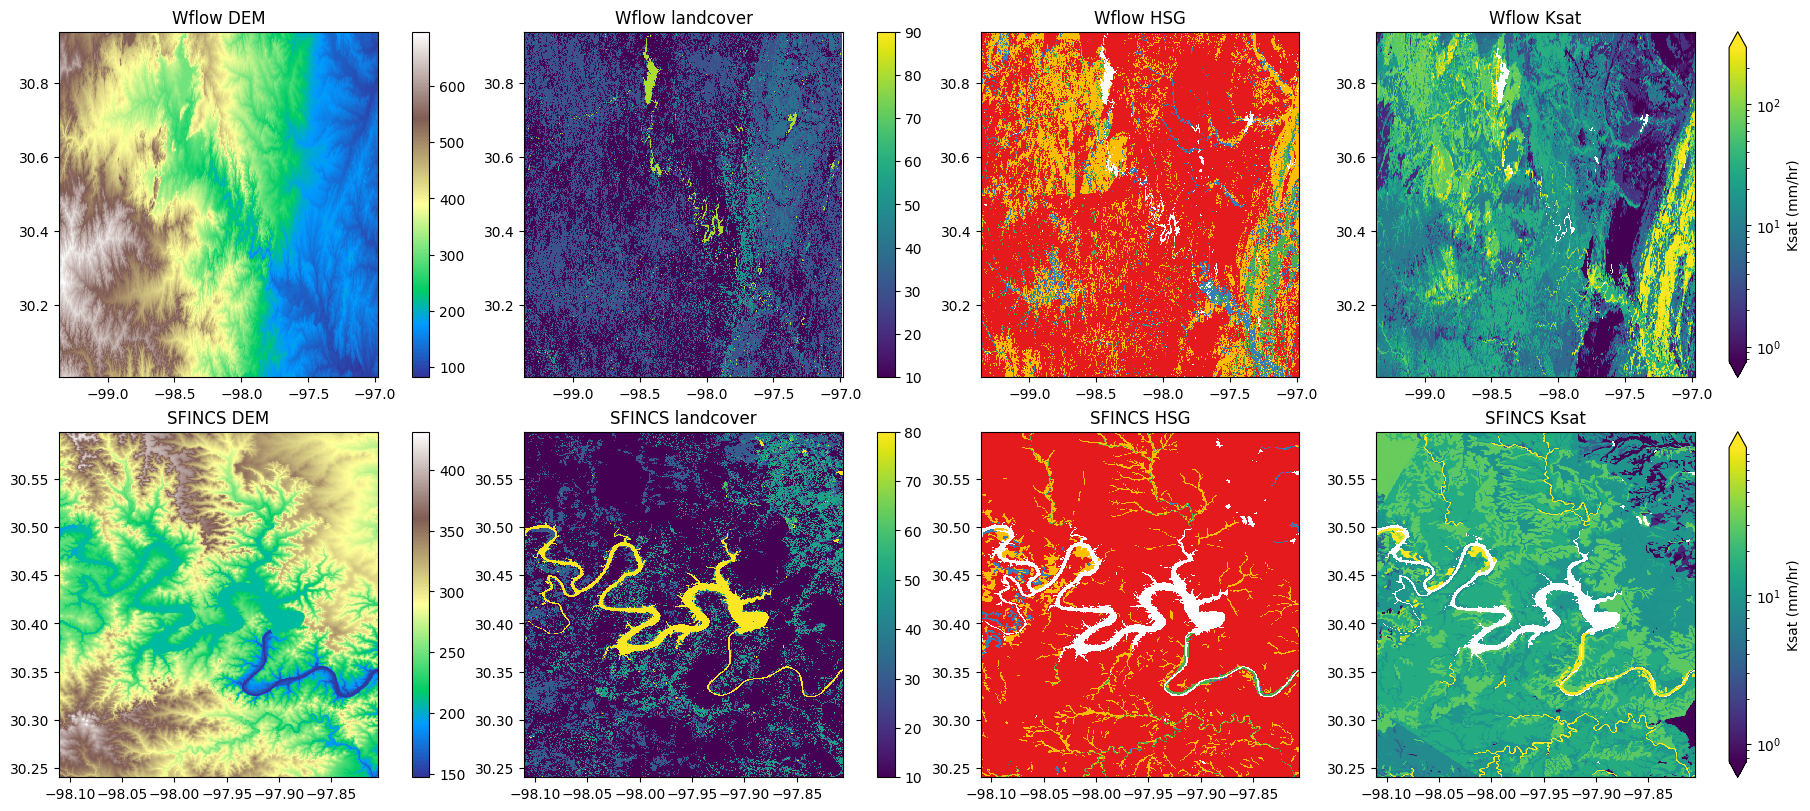

In [5]:
static_plot = region.plot_collected_inland_static_data(runtime)
if isinstance(static_plot, pd.DataFrame):
    display(static_plot)
else:
    plt.show()
